In [ ]:
!pip -q install "datasets>=2.19" pandas matplotlib pyarrow huggingface_hub

import itertools, json, collections, textwrap, re, random, statistics
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

REPO = "open-thoughts/AgentTrove"
random.seed(0)
print("✅ Imports ready. Target dataset:", REPO)

ds = load_dataset(REPO, split="train", streaming=True)
print("✅ Streaming dataset opened.")

first = next(iter(ds))
print("\n🔎 Columns present in a row:")
for k in first.keys():
    v = first[k]
    t = type(v).__name__
    preview = (str(v)[:70] + "…") if v is not None and len(str(v)) > 70 else v
    print(f"   • {k:<18} ({t}): {preview}")

In [ ]:
def find_trace_key(row):
    for cand in ("conversations", "messages"):
        if cand in row and isinstance(row[cand], list):
            return cand
    for k, v in row.items():
        if isinstance(v, list) and v and isinstance(v[0], dict) and \
           ("content" in v[0] or "role" in v[0] or "value" in v[0]):
            return k
    raise KeyError("No conversation-like column found.")

TRACE_KEY = find_trace_key(first)
print(f"\n✅ Trace column detected: '{TRACE_KEY}'")

def normalize_turns(trace):
    turns = []
    for turn in trace:
        if not isinstance(turn, dict):
            turns.append(("unknown", str(turn)))
            continue
        role = turn.get("role") or turn.get("from") or "unknown"
        content = turn.get("content")
        if content is None:
            content = turn.get("value", "")
        turns.append((str(role), "" if content is None else str(content)))
    return turns

sample_turns = normalize_turns(first[TRACE_KEY])
print(f"✅ First trace has {len(sample_turns)} turns. "
      f"Roles: {collections.Counter(r for r, _ in sample_turns)}")

In [ ]:
def extract_commands(assistant_content):
    """Best-effort: pull shell commands out of an assistant JSON turn."""
    cmds = []
    txt = re.sub(r"```(?:json)?|```", "", assistant_content).strip()
    try:
        obj = json.loads(txt)
    except Exception:
        return cmds
    def walk(o):
        if isinstance(o, dict):
            for key in ("commands", "command", "keystrokes", "cmd", "action"):
                if key in o:
                    val = o[key]
                    if isinstance(val, str):
                        cmds.append(val.strip())
                    elif isinstance(val, list):
                        for item in val:
                            if isinstance(item, str):
                                cmds.append(item.strip())
                            elif isinstance(item, dict):
                                walk(item)
            for v in o.values():
                if isinstance(v, (dict, list)):
                    walk(v)
        elif isinstance(o, list):
            for v in o:
                walk(v)
    walk(obj)
    return [c for c in cmds if c]

In [ ]:
def render_trace(row, max_chars=600):
    meta = {k: row.get(k) for k in
            ("original_source", "original_teacher", "model", "task",
             "result", "reward", "model_provider") if k in row}
    print("=" * 78)
    print("📦 METADATA:", {k: v for k, v in meta.items() if v is not None})
    print("=" * 78)
    for i, (role, content) in enumerate(normalize_turns(row[TRACE_KEY])):
        tag = {"system": "⚙️ SYSTEM", "user": "👤 USER",
               "assistant": "🤖 ASSISTANT", "tool": "🛠️ TOOL"}.get(role, f"❓ {role.upper()}")
        snippet = content if len(content) <= max_chars else content[:max_chars] + " …[truncated]"
        print(f"\n[{i}] {tag}")
        print(textwrap.indent(snippet, "    "))
        if role == "assistant":
            for c in extract_commands(content)[:5]:
                print(f"      └─⌨️  parsed command: {c!r}")
    print("=" * 78, "\n")

print("\n📜 EXAMPLE TRAJECTORY (first row):")
render_trace(first, max_chars=400)

In [ ]:
N = 2000
records = []
print(f"\n⏳ Streaming {N} rows for analysis…")
for row in itertools.islice(load_dataset(REPO, split="train", streaming=True), N):
    turns = normalize_turns(row[TRACE_KEY])
    roles = collections.Counter(r for r, _ in turns)
    total_chars = sum(len(c) for _, c in turns)
    asst_cmds = sum(len(extract_commands(c)) for r, c in turns if r == "assistant")
    records.append({
        "original_source":  row.get("original_source"),
        "original_teacher": row.get("original_teacher"),
        "model":            row.get("model"),
        "model_provider":   row.get("model_provider"),
        "result":           row.get("result"),
        "reward":           row.get("reward"),
        "n_turns":          len(turns),
        "n_user":           roles.get("user", 0),
        "n_assistant":      roles.get("assistant", 0),
        "n_tool":           roles.get("tool", 0),
        "total_chars":      total_chars,
        "n_commands":       asst_cmds,
    })

df = pd.DataFrame(records)
print(f"✅ Built DataFrame: {df.shape[0]} rows × {df.shape[1]} cols")
print("\n📊 Numeric summary (turns / length / commands):")
print(df[["n_turns", "n_assistant", "n_tool", "total_chars", "n_commands"]]
      .describe().round(1).to_string())

def show_dist(col, top=15):
    if col in df and df[col].notna().any():
        print(f"\n🏷️  Top values for '{col}':")
        print(df[col].value_counts(dropna=True).head(top).to_string())
    else:
        print(f"\n🏷️  '{col}' is empty/absent in this sample.")

for c in ("original_source", "original_teacher", "model", "model_provider", "result"):
    show_dist(c)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

src = df["original_source"].value_counts().head(10)
axes[0, 0].barh(src.index[::-1], src.values[::-1], color="#4C72B0")
axes[0, 0].set_title("Top 10 Task Sources"); axes[0, 0].set_xlabel("traces")

tch = df["original_teacher"].value_counts().head(10)
axes[0, 1].barh(tch.index[::-1], tch.values[::-1], color="#55A868")
axes[0, 1].set_title("Teacher Models"); axes[0, 1].set_xlabel("traces")

axes[1, 0].hist(df["n_turns"].clip(upper=df["n_turns"].quantile(0.97)),
                bins=30, color="#C44E52", edgecolor="white")
axes[1, 0].set_title("Turns per Trajectory (97th-pct clipped)")
axes[1, 0].set_xlabel("turns"); axes[1, 0].set_ylabel("count")

axes[1, 1].scatter(df["n_assistant"], df["n_commands"], alpha=0.3, s=12, color="#8172B2")
axes[1, 1].set_title("Assistant Turns vs. Parsed Commands")
axes[1, 1].set_xlabel("assistant turns"); axes[1, 1].set_ylabel("shell commands extracted")

plt.tight_layout(); plt.show()

✅ Imports ready. Target dataset: open-thoughts/AgentTrove


README.md:   0%|          | 0.00/18.9k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

✅ Streaming dataset opened.

🔎 Columns present in a row:
   • conversations      (list): [{'content': 'You are an AI assistant tasked with solving command-line…
   • agent              (str): terminus-2
   • model              (str): gpt-5-nano-2025-08-07
   • date               (str): 2025-10-04T08:32:59.395236
   • task               (NoneType): None
   • episode            (str): episode-7
   • run_id             (str): b84cca06-f1ef-4191-9c45-87ddf92df94a
   • trial_name         (str): code_contests-0000__c8ZdrpP
   • model_provider     (NoneType): None
   • original_source    (str): code_contests
   • original_teacher   (str): GPT-5-mini
   • result             (NoneType): None
   • trace_source       (NoneType): None
   • path               (NoneType): None
   • task_binary        (NoneType): None
   • instruction        (NoneType): None
   • verifier_output    (NoneType): None
   • ground_truth       (NoneType): None
   • judgment           (NoneType): None
   • __index_level_0_

Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

✅ Built DataFrame: 2000 rows × 12 cols

📊 Numeric summary (turns / length / commands):
       n_turns  n_assistant  n_tool  total_chars  n_commands
count   2000.0       2000.0  2000.0       2000.0      2000.0
mean       9.8          4.9     0.0      25127.6        25.2
std        5.2          2.6     0.0      18694.2        21.9
min        4.0          2.0     0.0       5594.0         0.0
25%        4.0          2.0     0.0      11403.8         8.0
50%        8.0          4.0     0.0      18112.5        18.0
75%       16.0          8.0     0.0      33433.8        36.0
max       16.0          8.0     0.0     136913.0       196.0

🏷️  Top values for 'original_source':
original_source
code_contests    2000

🏷️  Top values for 'original_teacher':
original_teacher
GPT-5-mini    2000

🏷️  Top values for 'model':
model
gpt-5-nano-2025-08-07    2000

🏷️  'model_provider' is empty/absent in this sample.

🏷️  'result' is empty/absent in this sample.


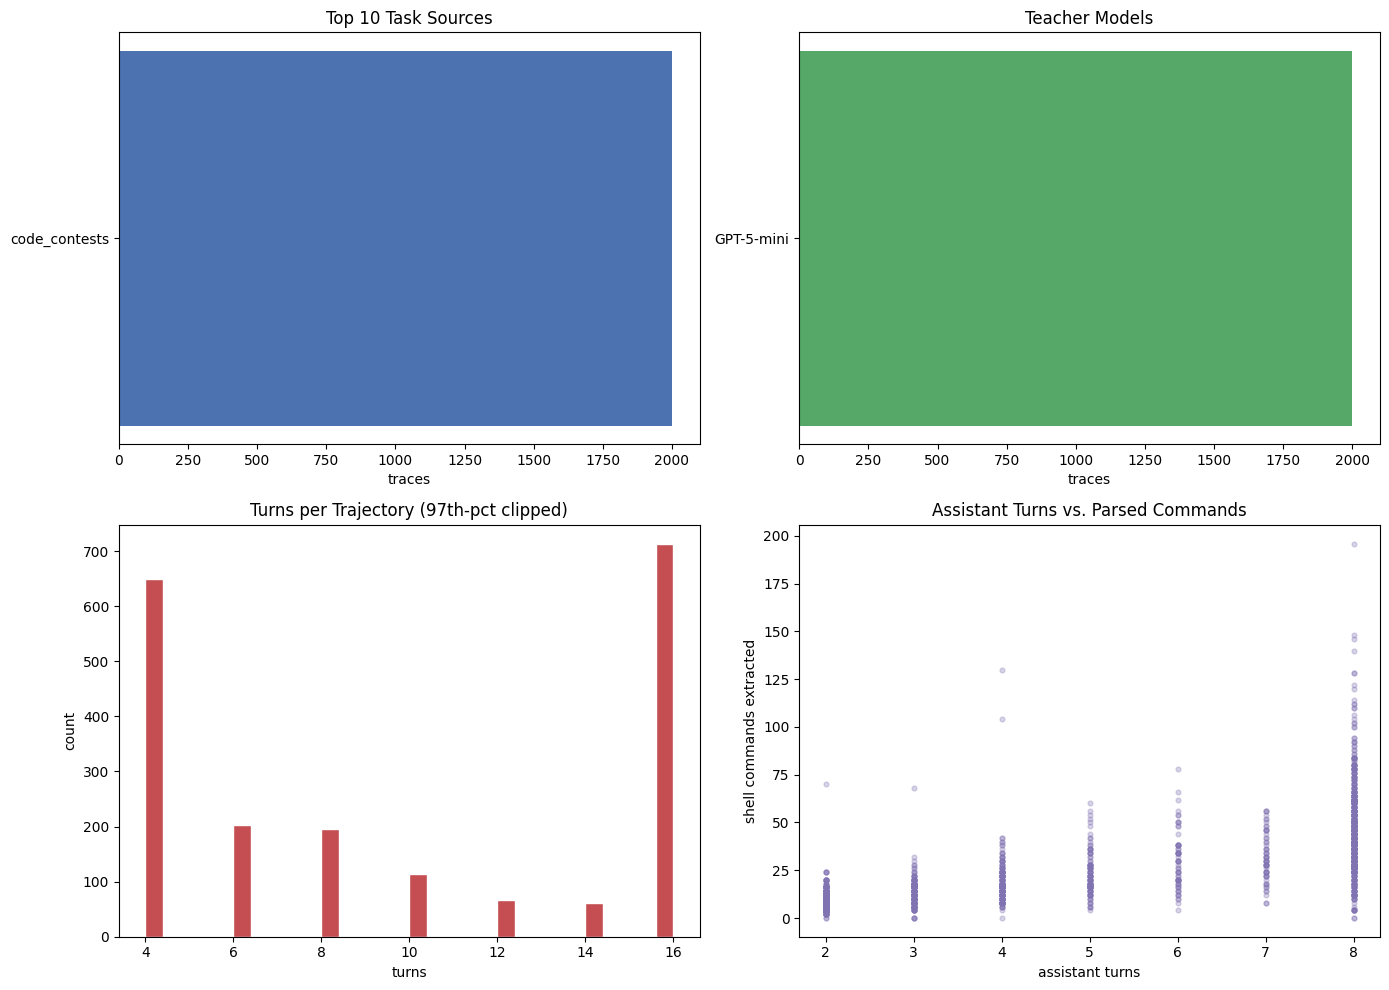


⏳ Scanning up to 1500 rows, keeping up to 200 successful traces…


Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

✅ Scanned 1500 rows → wrote 0 clean traces to 'agenttrove_clean_sft.jsonl'

🔍 Searching for 'nl2bash' source traces:


Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

No matches in the scanned window — try increasing `scan`.

🎉 Tutorial complete! Next ideas:
   • Increase N / SCAN for bigger analyses.
   • Filter by original_source (swesmith, codeforces, r2egym…) for a domain SFT set.
   • Feed agenttrove_clean_sft.jsonl into Axolotl / LLaMA-Factory for fine-tuning.


In [2]:
def is_success(row):
    res = (row.get("result") or "").lower()
    if res in ("resolved", "success", "pass", "passed", "correct"):
        return True
    rw = row.get("reward")
    try:
        return float(rw) >= 1.0
    except (TypeError, ValueError):
        return False

out_path = "agenttrove_clean_sft.jsonl"
kept, scanned, SCAN, KEEP = 0, 0, 1500, 200
print(f"\n⏳ Scanning up to {SCAN} rows, keeping up to {KEEP} successful traces…")
with open(out_path, "w") as f:
    for row in itertools.islice(load_dataset(REPO, split="train", streaming=True), SCAN):
        scanned += 1
        if not is_success(row):
            continue
        turns = normalize_turns(row[TRACE_KEY])
        conv = [{"from": r, "value": c} for r, c in turns if c.strip()]
        if len(conv) < 2:
            continue
        f.write(json.dumps({
            "conversations": conv,
            "source": row.get("original_source"),
            "teacher": row.get("original_teacher"),
        }) + "\n")
        kept += 1
        if kept >= KEEP:
            break
print(f"✅ Scanned {scanned} rows → wrote {kept} clean traces to '{out_path}'")

def search_traces(keyword=None, source=None, limit=3, scan=3000):
    """Stream the dataset and yield-print traces matching filters."""
    hits = 0
    for row in itertools.islice(load_dataset(REPO, split="train", streaming=True), scan):
        if source and row.get("original_source") != source:
            continue
        if keyword:
            blob = " ".join(c for _, c in normalize_turns(row[TRACE_KEY]))
            if keyword.lower() not in blob.lower():
                continue
        render_trace(row, max_chars=300)
        hits += 1
        if hits >= limit:
            break
    if hits == 0:
        print("No matches in the scanned window — try increasing `scan`.")

print("\n🔍 Searching for 'nl2bash' source traces:")
search_traces(source="nl2bash", limit=2, scan=4000)

print("\n🎉 Tutorial complete! Next ideas:")
print("   • Increase N / SCAN for bigger analyses.")
print("   • Filter by original_source (swesmith, codeforces, r2egym…) for a domain SFT set.")
print("   • Feed agenttrove_clean_sft.jsonl into Axolotl / LLaMA-Factory for fine-tuning.")